### 아래 예제 재사용

ch10 > sec02 > 01_conditional_tools.ipynb

#### Case1: Streamable HTTP

In [22]:
# https://github.com/langchain-ai/langchain-mcp-adapters?tab=readme-ov-file#streamable-http

from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client

# from langgraph.prebuilt import create_react_agent
from langchain_mcp_adapters.tools import load_mcp_tools

async with streamablehttp_client("http://127.0.0.1:8000/mcp/") as (read, write, _):
    async with ClientSession(read, write) as session:
        # Initialize the connection
        await session.initialize()

        # Get tools
        tools = await load_mcp_tools(session)
        # agent = create_react_agent("openai:gpt-4.1", tools)
        # math_response = await agent.ainvoke({"messages": "what's (3 + 5) x 12?"})

In [6]:
tools

[StructuredTool(name='hello', description='간단한 인사말을 반환하는 도구', args_schema={'properties': {'name': {'default': '아무개', 'title': 'Name', 'type': 'string'}}, 'title': 'helloArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000015F45FB9B20>),
 StructuredTool(name='get_current_time', description="현재 시각을 반환하는 함수\n\nArgs:\n    timezone (str): 타임존 (예: 'Asia/Seoul') 실제 존재하는 타임존이어야 함\n    location (str): 지역명. 타임존이 모든 지명에 대응되지 않기 때문에 이후 llm 답변 생성에 사용됨\n", args_schema={'properties': {'timezone': {'default': 'Asia/Seoul', 'title': 'Timezone', 'type': 'string'}, 'location': {'default': '부산', 'title': 'Location', 'type': 'string'}}, 'title': 'get_current_timeArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000015F45FBADE0>),
 StructuredTool(name='get_yf_stock_history', description='주식 종목의 가격 데이터를 조회하는 

In [14]:
tools=None

#### Case2: Using with LangGraph StateGraph

In [1]:
# https://github.com/langchain-ai/langchain-mcp-adapters?tab=readme-ov-file#using-with-langgraph-stategraph

from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.graph import StateGraph, MessagesState, START
# from langgraph.prebuilt import ToolNode, tools_condition

# from langchain.chat_models import init_chat_model
# model = init_chat_model("openai:gpt-4.1")

client = MultiServerMCPClient(
    {
        "my_tools": {
            "url": "http://127.0.0.1:8000/mcp/",
            "transport": "streamable_http",
        }
    }
)
tools = await client.get_tools()

In [2]:
tools

[StructuredTool(name='hello', description='간단한 인사말을 반환하는 도구', args_schema={'properties': {'name': {'default': '아무개', 'title': 'Name', 'type': 'string'}}, 'title': 'helloArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000021877346660>),
 StructuredTool(name='get_current_time', description="현재 시각을 반환하는 함수\n\nArgs:\n    timezone (str): 타임존 (예: 'Asia/Seoul') 실제 존재하는 타임존이어야 함\n    location (str): 지역명. 타임존이 모든 지명에 대응되지 않기 때문에 이후 llm 답변 생성에 사용됨\n", args_schema={'properties': {'timezone': {'default': 'Asia/Seoul', 'title': 'Timezone', 'type': 'string'}, 'location': {'default': '부산', 'title': 'Location', 'type': 'string'}}, 'title': 'get_current_timeArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x00000218773454E0>),
 StructuredTool(name='get_yf_stock_history', description='주식 종목의 가격 데이터를 조회하는 

In [3]:
# MCP 도구 테스트
async def main():
    # 'hello' 도구를 비동기적으로 실행하고 결과를 result 변수에 할당
    # MCP는 서버이기 때문에 네트워크로 비동기 통신함
    result = await tools[0].ainvoke({"name": "김일남"})
    print(result)

await main()

안녕하세요, 김일남님!


In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [5]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [6]:
from langgraph.graph import StateGraph

# 그래프 구성
graph_builder = StateGraph(State)

In [ ]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

# * 비동기 적용
async def generate(state: State):
    return {"messages": await model_with_tools.ainvoke(state["messages"])} # ainvoke() 비동기 

graph_builder.add_node("generate", generate)

In [8]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [9]:
from langgraph.graph import START, END

def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
        
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [10]:
graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")

In [11]:
graph = graph_builder.compile()

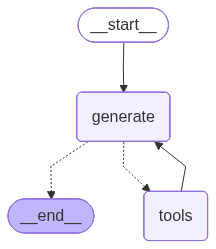

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 부산 몇시야?")]

gathered = None

# 비동기 처리
async for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

TypeError: 'async for' requires an object with __aiter__ method, got generator

In [16]:
async def run_graph():
    inputs = [HumanMessage(content="지금 부산 몇시야?")]
    
    # graph.astream_events는 (event_dict,) 또는 (event_dict, metadata)를 반환할 수 있으므로
    # for msg in ... 형태로 수정하거나, 반환되는 튜플을 정확히 언패킹해야 합니다.
    # 여기서는 msg를 단일 변수로 받습니다.
    async for msg in graph.astream_events({"messages": inputs}, version="v1"):
        if msg["event"] == "on_tool_end":
            print(f'Tool Call: {msg["name"]}')
            print(f'Tool Output: {msg["data"]["output"]}')
        elif msg["event"] == "on_chat_model_stream":
            print(msg["data"]["chunk"].content, end='')

await run_graph()

TypeError: object AIMessage can't be used in 'await' expression

In [62]:
inputs = {"messages": [("user", "오늘 테슬라 주가 알려줘")]}
for s in graph.stream(inputs, stream_mode="values"):
    print(s)

{'messages': [HumanMessage(content='오늘 테슬라 주가 알려줘', additional_kwargs={}, response_metadata={}, id='5518a85b-be09-4e59-876c-89d7198e187a')]}
{'messages': [HumanMessage(content='오늘 테슬라 주가 알려줘', additional_kwargs={}, response_metadata={}, id='5518a85b-be09-4e59-876c-89d7198e187a'), AIMessage(content='테슬라 주가를 알려면 기간을 설정해야 하는데, 얼마 동안의 주가를 알려드릴까요? (예: 1일, 1달, 1년)', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--9e31649b-8312-41c4-9c43-68c113814d1d-0', usage_metadata={'input_tokens': 179, 'output_tokens': 46, 'total_tokens': 225, 'input_token_details': {'cache_read': 0}})]}


In [20]:
gathered

AIMessageChunk(content='지금 부산은 2025년 9월 18일 11시 12분 23초입니다.\n', additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}'}}, response_metadata={'finish_reason': 'STOPSTOP', 'model_name': 'gemini-2.0-flashgemini-2.0-flash', 'safety_ratings': []}, id='run--5f1c1432-e4a1-4a5f-893f-ab8436ddfd0c', tool_calls=[{'name': 'get_current_time', 'args': {'location': '부산', 'timezone': 'Asia/Seoul'}, 'id': '4d003487-998d-4c2c-ada8-761c44e08977', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'output_tokens': 45, 'total_tokens': 254, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "\\ubd80\\uc0b0", "timezone": "Asia/Seoul"}', 'id': '4d003487-998d-4c2c-ada8-761c44e08977', 'index': None, 'type': 'tool_call_chunk'}])